/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed


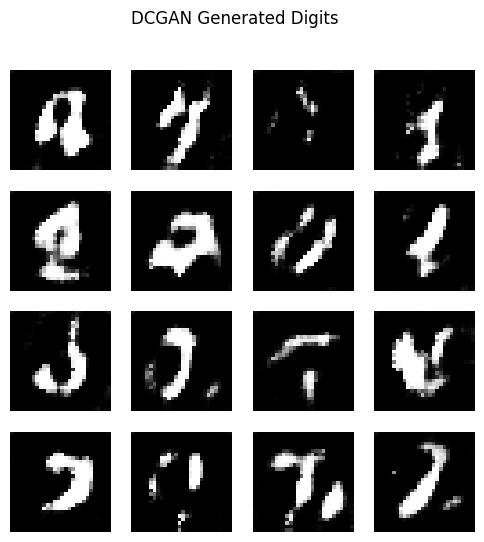

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------
# Load MNIST Dataset
# -----------------------------------
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize images to [-1,1]
x_train = (x_train.astype("float32") - 127.5) / 127.5

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)

# Reduce dataset size for faster training
x_train = x_train[:10000]

BATCH_SIZE = 64

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(10000).batch(BATCH_SIZE)

# -----------------------------------
# Generator
# -----------------------------------
def build_generator():

    model = tf.keras.Sequential()

    model.add(layers.Dense(
        7 * 7 * 128,
        use_bias=False,
        input_shape=(100,)
    ))

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 128)))

    model.add(layers.Conv2DTranspose(
        64,
        (5,5),
        strides=(2,2),
        padding='same',
        use_bias=False
    ))

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(
        1,
        (5,5),
        strides=(2,2),
        padding='same',
        use_bias=False,
        activation='tanh'
    ))

    return model

generator = build_generator()

# -----------------------------------
# Discriminator
# -----------------------------------
def build_discriminator():

    model = tf.keras.Sequential()

    model.add(layers.Conv2D(
        64,
        (5,5),
        strides=(2,2),
        padding='same',
        input_shape=(28,28,1)
    ))

    model.add(layers.LeakyReLU())

    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(
        128,
        (5,5),
        strides=(2,2),
        padding='same'
    ))

    model.add(layers.LeakyReLU())

    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())

    model.add(layers.Dense(1, activation='sigmoid'))

    return model

discriminator = build_discriminator()

# -----------------------------------
# Compile Discriminator
# -----------------------------------
discriminator.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -----------------------------------
# Combined GAN
# -----------------------------------
discriminator.trainable = False

gan_input = tf.keras.Input(shape=(100,))

fake_image = generator(gan_input)

gan_output = discriminator(fake_image)

gan = tf.keras.Model(gan_input, gan_output)

gan.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# -----------------------------------
# Training
# -----------------------------------
EPOCHS = 5
noise_dim = 100

for epoch in range(EPOCHS):

    for real_images in dataset:

        batch_size = real_images.shape[0]

        # Generate fake images
        noise = np.random.normal(
            0, 1,
            (batch_size, noise_dim)
        )

        fake_images = generator.predict(
            noise,
            verbose=0
        )

        # Labels
        real_labels = np.ones((batch_size, 1))
        fake_labels = np.zeros((batch_size, 1))

        # Train discriminator
        discriminator.trainable = True

        d_loss_real = discriminator.train_on_batch(
            real_images,
            real_labels
        )

        d_loss_fake = discriminator.train_on_batch(
            fake_images,
            fake_labels
        )

        # Train generator
        discriminator.trainable = False

        noise = np.random.normal(
            0, 1,
            (batch_size, noise_dim)
        )

        gan_loss = gan.train_on_batch(
            noise,
            real_labels
        )

    print(f"Epoch {epoch+1} completed")

# -----------------------------------
# Generate Images
# -----------------------------------
noise = np.random.normal(0, 1, (16, noise_dim))

generated_images = generator.predict(noise, verbose=0)

# Rescale images
generated_images = 0.5 * generated_images + 0.5

# -----------------------------------
# Display Images
# -----------------------------------
plt.figure(figsize=(6,6))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        generated_images[i, :, :, 0],
        cmap='gray'
    )

    plt.axis('off')

plt.suptitle("DCGAN Generated Digits")
plt.show()